# HGNN with HyperEdge using 1-hop Neighbour Method

In [1]:
# =========================
# STEP 1: Install & Imports
# =========================

!pip install torch-geometric -q

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.datasets import Planetoid
from torch_geometric.utils import to_undirected
from torch_geometric.transforms import NormalizeFeatures

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =========================
# Load Cora
# =========================

dataset = Planetoid(
    root='/kaggle/working/Cora',
    name='Cora',
    transform=NormalizeFeatures()
)

data = dataset[0].to(device)

print("Number of nodes:", data.num_nodes)
print("Number of edges:", data.num_edges)
print("Number of features:", dataset.num_node_features)
print("Number of classes:", dataset.num_classes)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 18.0 MB/s eta 0:00:0000:0100:01
Using device: cuda


Processing...
Done!


Number of nodes: 2708
Number of edges: 10556
Number of features: 1433
Number of classes: 7


In [18]:
# =====================================
# STEP 2: Build Sparse Incidence Matrix H
# =====================================

from torch_geometric.utils import add_self_loops

# Ensure graph is undirected
edge_index = to_undirected(data.edge_index)

# Add self loops (for node + its neighbors hyperedge)
edge_index, _ = add_self_loops(edge_index, num_nodes=data.num_nodes)

# Build sparse incidence matrix H
# Shape: [num_nodes, num_hyperedges]
# Here: num_hyperedges = num_nodes

row = edge_index[0]
col = edge_index[1]

values = torch.ones(row.size(0), device=device)

H = torch.sparse_coo_tensor(
    torch.stack([row, col]),
    values,
    size=(data.num_nodes, data.num_nodes)
).coalesce()

print("H shape:", H.shape)
print("Number of non-zeros in H:", H._nnz())


H shape: torch.Size([2708, 2708])
Number of non-zeros in H: 13264


In [19]:
# =====================================
# STEP 3: Compute HGNN Propagation Matrix G
# =====================================

# ---- Vertex Degree Dv ----
# dv[i] = sum_j H[i, j]

dv = torch.sparse.sum(H, dim=1).to_dense()
dv_inv_sqrt = torch.pow(dv, -0.5)
dv_inv_sqrt[dv_inv_sqrt == float('inf')] = 0

Dv_inv_sqrt = torch.sparse_coo_tensor(
    torch.stack([torch.arange(data.num_nodes, device=device),
                 torch.arange(data.num_nodes, device=device)]),
    dv_inv_sqrt,
    size=(data.num_nodes, data.num_nodes)
)

# ---- Hyperedge Degree De ----
# de[j] = sum_i H[i, j]

de = torch.sparse.sum(H, dim=0).to_dense()
de_inv = torch.pow(de, -1.0)
de_inv[de_inv == float('inf')] = 0

De_inv = torch.sparse_coo_tensor(
    torch.stack([torch.arange(data.num_nodes, device=device),
                 torch.arange(data.num_nodes, device=device)]),
    de_inv,
    size=(data.num_nodes, data.num_nodes)
)

# ---- Compute G = Dv^-1/2 H De^-1 H^T Dv^-1/2 ----

# Step 1: H De^-1
H_De = torch.sparse.mm(H, De_inv)

# Step 2: H De^-1 H^T
H_De_HT = torch.sparse.mm(H_De, H.transpose(0,1))

# Step 3: Dv^-1/2 (H De^-1 H^T)
Dv_left = torch.sparse.mm(Dv_inv_sqrt, H_De_HT)

# Step 4: Full G
G = torch.sparse.mm(Dv_left, Dv_inv_sqrt).coalesce()

print("G shape:", G.shape)
print("Number of non-zeros in G:", G._nnz())


G shape: torch.Size([2708, 2708])
Number of non-zeros in G: 99596


In [72]:
# =====================================
# STEP 4: Define HGNN Layer and Model
# =====================================

class HGNNLayer(nn.Module):
    def __init__(self, in_features, out_features, bias=True):
        super(HGNNLayer, self).__init__()
        self.linear = nn.Linear(in_features, out_features, bias=bias)

    def forward(self, x, G):
        x = self.linear(x)
        x = torch.sparse.mm(G, x)
        return x


class HGNN(nn.Module):
    def __init__(self, in_features, hidden_dim, num_classes, dropout=0.5):
        super(HGNN, self).__init__()

        self.h1 = HGNNLayer(in_features, hidden_dim)
        self.h2 = HGNNLayer(hidden_dim, num_classes)
        self.dropout = dropout

    def forward(self, x, G):
        x = self.h1(x, G)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.h2(x, G)
        return x


# Initialize model
model = HGNN(
    in_features=dataset.num_node_features,
    hidden_dim=16,
    num_classes=dataset.num_classes,
    dropout=0.5
).to(device)

print(model)


HGNN(
  (h1): HGNNLayer(
    (linear): Linear(in_features=1433, out_features=16, bias=True)
  )
  (h2): HGNNLayer(
    (linear): Linear(in_features=16, out_features=7, bias=True)
  )
)


Epoch 010 | Loss: 1.9123 | Train Acc: 0.2929 | Val Acc: 0.1580 | Test Acc: 0.1740
Epoch 020 | Loss: 1.8359 | Train Acc: 0.3857 | Val Acc: 0.2620 | Test Acc: 0.2700
Epoch 030 | Loss: 1.7179 | Train Acc: 0.7714 | Val Acc: 0.4880 | Test Acc: 0.5100
Epoch 040 | Loss: 1.5544 | Train Acc: 0.8571 | Val Acc: 0.6180 | Test Acc: 0.6280
Epoch 050 | Loss: 1.3878 | Train Acc: 0.8857 | Val Acc: 0.6760 | Test Acc: 0.7010
Epoch 060 | Loss: 1.1874 | Train Acc: 0.9000 | Val Acc: 0.7280 | Test Acc: 0.7340
Epoch 070 | Loss: 1.0504 | Train Acc: 0.9071 | Val Acc: 0.7660 | Test Acc: 0.7780
Epoch 080 | Loss: 0.8909 | Train Acc: 0.9286 | Val Acc: 0.7780 | Test Acc: 0.7910
Epoch 090 | Loss: 0.7687 | Train Acc: 0.9429 | Val Acc: 0.7760 | Test Acc: 0.7870
Epoch 100 | Loss: 0.7123 | Train Acc: 0.9500 | Val Acc: 0.7860 | Test Acc: 0.7860
Epoch 110 | Loss: 0.6661 | Train Acc: 0.9500 | Val Acc: 0.7780 | Test Acc: 0.7940
Epoch 120 | Loss: 0.6241 | Train Acc: 0.9714 | Val Acc: 0.7880 | Test Acc: 0.7960
Epoch 130 | Loss

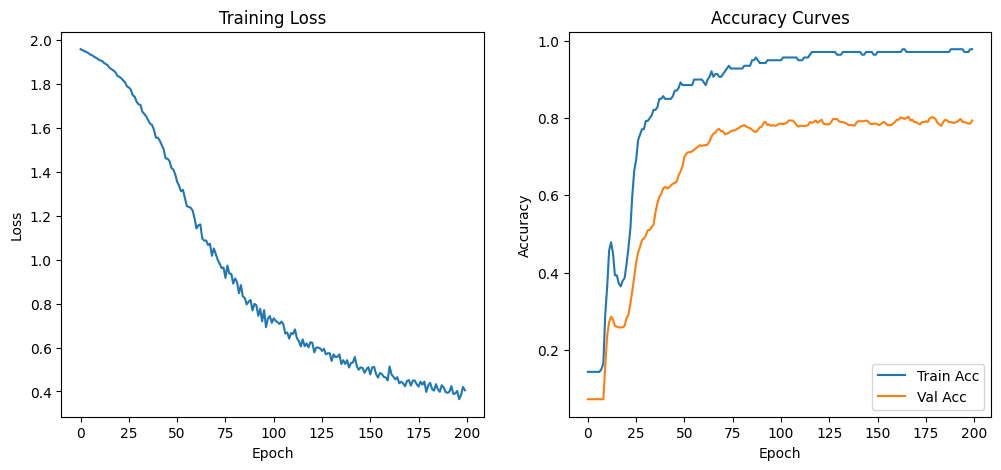

In [21]:
# =====================================
# TRAINING LOOP WITH CURVES
# =====================================

import matplotlib.pyplot as plt

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01,
    weight_decay=5e-4
)

criterion = nn.CrossEntropyLoss()

train_mask = data.train_mask
val_mask = data.val_mask
test_mask = data.test_mask

best_val_acc = 0
patience = 50
patience_counter = 0
best_model_state = None

# ---- Track Metrics ----
train_losses = []
train_accs = []
val_accs = []

for epoch in range(1, 201):

    model.train()
    optimizer.zero_grad()

    out = model(data.x, G)
    loss = criterion(out[train_mask], data.y[train_mask])
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        out = model(data.x, G)
        pred = out.argmax(dim=1)

        train_acc = (pred[train_mask] == data.y[train_mask]).float().mean()
        val_acc = (pred[val_mask] == data.y[val_mask]).float().mean()
        test_acc = (pred[test_mask] == data.y[test_mask]).float().mean()

    # ---- Store metrics ----
    train_losses.append(loss.item())
    train_accs.append(train_acc.item())
    val_accs.append(val_acc.item())

    # ---- Early stopping ----
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | "
              f"Loss: {loss:.4f} | "
              f"Train Acc: {train_acc:.4f} | "
              f"Val Acc: {val_acc:.4f} | "
              f"Test Acc: {test_acc:.4f}")

    if patience_counter >= patience:
        print("Early stopping triggered.")
        break

# Load best model
model.load_state_dict(best_model_state)

# Final test accuracy
model.eval()
with torch.no_grad():
    out = model(data.x, G)
    pred = out.argmax(dim=1)
    final_test_acc = (pred[test_mask] == data.y[test_mask]).float().mean()

print("\nFinal Test Accuracy:", final_test_acc.item())

# =====================================
# Plot Curves
# =====================================

plt.figure(figsize=(12,5))

# Loss Curve
plt.subplot(1,2,1)
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Accuracy Curve
plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.title("Accuracy Curves")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()


# KNN based hypergraph method

In [22]:
# =====================================
# STEP 6 (FIXED): Manual KNN Hypergraph
# =====================================

K = 5  # number of neighbors

# Normalize features for cosine similarity
x_norm = F.normalize(data.x, p=2, dim=1)

# Compute cosine similarity matrix
sim_matrix = torch.mm(x_norm, x_norm.t())

# Get top-K neighbors for each node
_, knn_indices = torch.topk(sim_matrix, k=K, dim=1)

# Build incidence matrix
row_indices = torch.arange(data.num_nodes, device=device).repeat_interleave(K)
col_indices = knn_indices.reshape(-1)

values = torch.ones(row_indices.size(0), device=device)

H_knn = torch.sparse_coo_tensor(
    torch.stack([row_indices, col_indices]),
    values,
    size=(data.num_nodes, data.num_nodes)
).coalesce()

print("H_knn shape:", H_knn.shape)
print("Non-zeros in H_knn:", H_knn._nnz())


H_knn shape: torch.Size([2708, 2708])
Non-zeros in H_knn: 13540


In [23]:
# =====================================
# STEP 7: Compute G for KNN Hypergraph
# =====================================

H = H_knn  # replace old H

# Vertex degree
dv = torch.sparse.sum(H, dim=1).to_dense()
dv_inv_sqrt = torch.pow(dv, -0.5)
dv_inv_sqrt[dv_inv_sqrt == float('inf')] = 0

Dv_inv_sqrt = torch.sparse_coo_tensor(
    torch.stack([torch.arange(data.num_nodes, device=device),
                 torch.arange(data.num_nodes, device=device)]),
    dv_inv_sqrt,
    size=(data.num_nodes, data.num_nodes)
)

# Hyperedge degree
de = torch.sparse.sum(H, dim=0).to_dense()
de_inv = torch.pow(de, -1.0)
de_inv[de_inv == float('inf')] = 0

De_inv = torch.sparse_coo_tensor(
    torch.stack([torch.arange(data.num_nodes, device=device),
                 torch.arange(data.num_nodes, device=device)]),
    de_inv,
    size=(data.num_nodes, data.num_nodes)
)

# Compute G
H_De = torch.sparse.mm(H, De_inv)
H_De_HT = torch.sparse.mm(H_De, H.transpose(0,1))
Dv_left = torch.sparse.mm(Dv_inv_sqrt, H_De_HT)
G = torch.sparse.mm(Dv_left, Dv_inv_sqrt).coalesce()

print("New G nnz:", G._nnz())


New G nnz: 119986


In [24]:
model = HGNN(
    in_features=dataset.num_node_features,
    hidden_dim=16,
    num_classes=dataset.num_classes,
    dropout=0.5
).to(device)


Epoch 010 | Loss: 1.9304 | Train Acc: 0.2429 | Val Acc: 0.2080 | Test Acc: 0.1800
Epoch 020 | Loss: 1.8903 | Train Acc: 0.6357 | Val Acc: 0.5020 | Test Acc: 0.5020
Epoch 030 | Loss: 1.8367 | Train Acc: 0.6643 | Val Acc: 0.5180 | Test Acc: 0.5320
Epoch 040 | Loss: 1.7397 | Train Acc: 0.7643 | Val Acc: 0.5860 | Test Acc: 0.6110
Epoch 050 | Loss: 1.6234 | Train Acc: 0.8071 | Val Acc: 0.6100 | Test Acc: 0.6330
Epoch 060 | Loss: 1.4808 | Train Acc: 0.7929 | Val Acc: 0.6300 | Test Acc: 0.6530
Epoch 070 | Loss: 1.3187 | Train Acc: 0.8071 | Val Acc: 0.6460 | Test Acc: 0.6560
Epoch 080 | Loss: 1.2198 | Train Acc: 0.8429 | Val Acc: 0.6520 | Test Acc: 0.6590
Epoch 090 | Loss: 1.0775 | Train Acc: 0.8643 | Val Acc: 0.6520 | Test Acc: 0.6600
Epoch 100 | Loss: 0.9809 | Train Acc: 0.8786 | Val Acc: 0.6400 | Test Acc: 0.6570
Epoch 110 | Loss: 0.8833 | Train Acc: 0.8786 | Val Acc: 0.6420 | Test Acc: 0.6590
Epoch 120 | Loss: 0.8338 | Train Acc: 0.8929 | Val Acc: 0.6560 | Test Acc: 0.6600
Epoch 130 | Loss

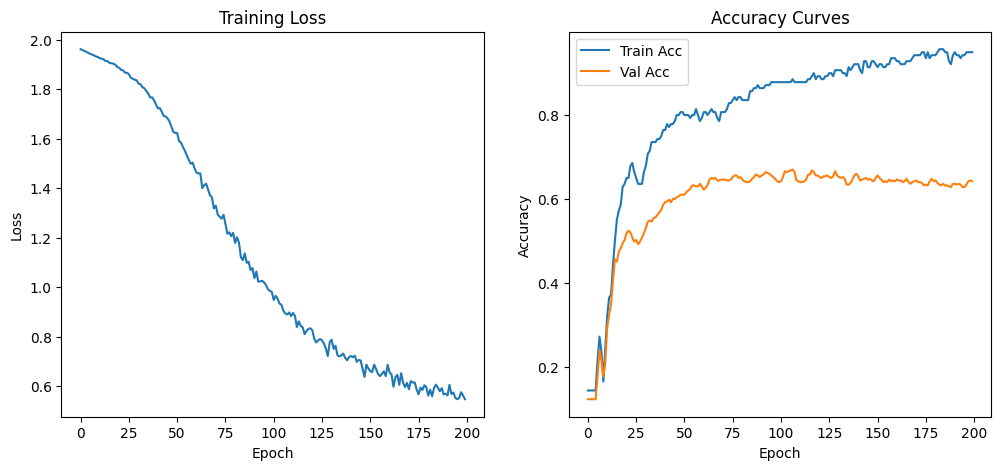

In [25]:
# =====================================
# TRAINING LOOP WITH CURVES
# =====================================

import matplotlib.pyplot as plt

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01,
    weight_decay=5e-4
)

criterion = nn.CrossEntropyLoss()

train_mask = data.train_mask
val_mask = data.val_mask
test_mask = data.test_mask

best_val_acc = 0
patience = 50
patience_counter = 0
best_model_state = None

# ---- Track Metrics ----
train_losses = []
train_accs = []
val_accs = []

for epoch in range(1, 201):

    model.train()
    optimizer.zero_grad()

    out = model(data.x, G)
    loss = criterion(out[train_mask], data.y[train_mask])
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        out = model(data.x, G)
        pred = out.argmax(dim=1)

        train_acc = (pred[train_mask] == data.y[train_mask]).float().mean()
        val_acc = (pred[val_mask] == data.y[val_mask]).float().mean()
        test_acc = (pred[test_mask] == data.y[test_mask]).float().mean()

    # ---- Store metrics ----
    train_losses.append(loss.item())
    train_accs.append(train_acc.item())
    val_accs.append(val_acc.item())

    # ---- Early stopping ----
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | "
              f"Loss: {loss:.4f} | "
              f"Train Acc: {train_acc:.4f} | "
              f"Val Acc: {val_acc:.4f} | "
              f"Test Acc: {test_acc:.4f}")

    # if patience_counter >= patience:
    #     print("Early stopping triggered.")
    #     break

# Load best model
model.load_state_dict(best_model_state)

# Final test accuracy
model.eval()
with torch.no_grad():
    out = model(data.x, G)
    pred = out.argmax(dim=1)
    final_test_acc = (pred[test_mask] == data.y[test_mask]).float().mean()

print("\nFinal Test Accuracy:", final_test_acc.item())

# =====================================
# Plot Curves
# =====================================

plt.figure(figsize=(12,5))

# Loss Curve
plt.subplot(1,2,1)
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Accuracy Curve
plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.title("Accuracy Curves")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()


Was so worse with K=10

# Hyperedge Modelling Using Dosage

In [61]:
G_nx


In [62]:
import math
import random
import networkx as nx

# ---------------------------
# Density
# ---------------------------
def DENSITY(G):
    if G.number_of_nodes() == 0:
        return 0
    return G.number_of_edges() / G.number_of_nodes()


# ---------------------------
# Distance between subgraphs
# ---------------------------
def DISTANCE(G1, G2):
    U = set(G1.nodes())
    Z = set(G2.nodes())
    
    if len(U) == 0 or len(Z) == 0:
        return 2
    
    if U == Z:
        return 0
    
    intersection = len(U.intersection(Z))
    return 2 - (intersection ** 2) / (len(U) * len(Z))


# ---------------------------
# Objective function
# ---------------------------
def OBJECTIVE(W, lam):
    total_density = sum(DENSITY(Gs) for Gs in W)
    
    total_distance = 0
    for i in range(len(W)):
        for j in range(i+1, len(W)):
            total_distance += DISTANCE(W[i], W[j])
    
    return total_density + lam * total_distance


In [63]:
def DENSESTSUBGRAPH(G, alpha, beta, delta):
    
    G_current = G.copy()
    G_best = None
    best_density = 0
    
    while G_current.number_of_nodes() > 0:
        
        n = G_current.number_of_nodes()
        
        if n < alpha:
            break
        
        # Diameter constraint
        try:
            if nx.is_connected(G_current):
                diam = nx.diameter(G_current)
            else:
                diam = float("inf")
        except:
            diam = float("inf")
        
        if diam <= delta and alpha <= n <= beta:
            d = DENSITY(G_current)
            if d > best_density:
                best_density = d
                G_best = G_current.copy()
        
        # Remove minimum-degree nodes (Goldberg peeling)
        degrees = dict(G_current.degree())
        min_deg = min(degrees.values())
        remove_nodes = [v for v, d in degrees.items() if d == min_deg]
        G_current.remove_nodes_from(remove_nodes)
    
    return G_best


In [65]:
def DENSESTDISTINCTSUBGRAPH(G, W, lam, alpha, beta, delta, trials=40):
    
    best_candidate = None
    best_obj = -1
    
    for _ in range(trials):
        
        # Random local region sampling
        seed = random.choice(list(G.nodes()))
        neighbors = list(nx.single_source_shortest_path_length(G, seed, cutoff=3).keys())
        
        if len(neighbors) < alpha:
            continue
        
        G_local = G.subgraph(neighbors).copy()
        
        G_candidate = DENSESTSUBGRAPH(G_local, alpha, beta, delta)
        
        if G_candidate is None:
            continue
        
        # Distinctness check
        distinct = True
        for G_prev in W:
            if DISTANCE(G_candidate, G_prev) == 0:
                distinct = False
                break
        
        if not distinct:
            continue
        
        W_temp = W + [G_candidate]
        obj = OBJECTIVE(W_temp, lam)
        
        if obj > best_obj:
            best_obj = obj
            best_candidate = G_candidate
    
    return best_candidate


In [66]:
def DOSAGE(G, k, lam, alpha, beta):
    
    # Compute delta
    if nx.is_connected(G):
        delta = 2 * nx.average_shortest_path_length(G)
    else:
        delta = math.log2(G.number_of_nodes())
    
    # Initial densest subgraph
    G_initial = DENSESTSUBGRAPH(G, alpha, beta, delta)
    
    if G_initial is None:
        W = []
    else:
        W = [G_initial]
        print(f"Hyperedge 1 | size={G_initial.number_of_nodes()} | dens={DENSITY(G_initial):.3f}")
    
    # Extract remaining
    while len(W) < k:
        
        G_next = DENSESTDISTINCTSUBGRAPH(G, W, lam, alpha, beta, delta)
        
        if G_next is None:
            break
        
        W.append(G_next)
        print(f"Hyperedge {len(W)} | size={G_next.number_of_nodes()} | dens={DENSITY(G_next):.3f}")
    
    return W


In [67]:
W = DOSAGE(
    G_nx,
    k=100,
    lam=0.3,
    alpha=5,
    beta=50
)

print("Total hyperedges:", len(W))

covered = set()
for s in W:
    covered.update(s.nodes())

print("Coverage:", len(covered))
print("Avg size:",
      sum(s.number_of_nodes() for s in W)/len(W))


Hyperedge 1 | size=6 | dens=2.167
Hyperedge 2 | size=47 | dens=3.043
Hyperedge 3 | size=38 | dens=3.105
Hyperedge 4 | size=20 | dens=2.900
Hyperedge 5 | size=14 | dens=2.929
Hyperedge 6 | size=27 | dens=2.963
Hyperedge 7 | size=27 | dens=2.593
Hyperedge 8 | size=9 | dens=2.556
Hyperedge 9 | size=26 | dens=2.692
Hyperedge 10 | size=26 | dens=3.000
Hyperedge 11 | size=7 | dens=2.571
Hyperedge 12 | size=39 | dens=2.538
Hyperedge 13 | size=10 | dens=2.500
Hyperedge 14 | size=9 | dens=2.556
Hyperedge 15 | size=27 | dens=2.407
Hyperedge 16 | size=19 | dens=2.895
Hyperedge 17 | size=10 | dens=2.400
Hyperedge 18 | size=36 | dens=3.111
Hyperedge 19 | size=32 | dens=2.375
Hyperedge 20 | size=14 | dens=2.571
Hyperedge 21 | size=19 | dens=2.368
Hyperedge 22 | size=13 | dens=2.385
Hyperedge 23 | size=7 | dens=2.286
Hyperedge 24 | size=6 | dens=2.333
Hyperedge 25 | size=10 | dens=2.300
Hyperedge 26 | size=17 | dens=2.353
Hyperedge 27 | size=22 | dens=2.727
Hyperedge 28 | size=13 | dens=2.923
Hypered

In [68]:
# =====================================
# STEP 6: Build Hypergraph from W
# =====================================

num_nodes = data.num_nodes
num_hyperedges = len(W)

rows = []
cols = []

for j, subgraph in enumerate(W):
    for node in subgraph.nodes():
        rows.append(node)
        cols.append(j)

rows = torch.tensor(rows, device=device)
cols = torch.tensor(cols, device=device)

values = torch.ones(len(rows), device=device)

H_dos = torch.sparse_coo_tensor(
    torch.stack([rows, cols]),
    values,
    size=(num_nodes, num_hyperedges)
).coalesce()

print("H shape:", H_dos.shape)
print("Nonzeros:", H_dos._nnz())


H shape: torch.Size([2708, 100])
Nonzeros: 2089


In [69]:
dv = torch.sparse.sum(H_dos, dim=1).to_dense()
print("Nodes with at least one hyperedge:",
      (dv > 0).sum().item())


Nodes with at least one hyperedge: 778


In [70]:
# =====================================
# STEP 7: Compute G
# =====================================

H = H_dos

# Vertex degree
dv = torch.sparse.sum(H, dim=1).to_dense()
dv_inv_sqrt = torch.pow(dv, -0.5)
dv_inv_sqrt[dv_inv_sqrt == float('inf')] = 0

Dv_inv_sqrt = torch.sparse_coo_tensor(
    torch.stack([torch.arange(num_nodes, device=device),
                 torch.arange(num_nodes, device=device)]),
    dv_inv_sqrt,
    size=(num_nodes, num_nodes)
)

# Hyperedge degree
de = torch.sparse.sum(H, dim=0).to_dense()
de_inv = torch.pow(de, -1.0)
de_inv[de_inv == float('inf')] = 0

De_inv = torch.sparse_coo_tensor(
    torch.stack([torch.arange(num_hyperedges, device=device),
                 torch.arange(num_hyperedges, device=device)]),
    de_inv,
    size=(num_hyperedges, num_hyperedges)
)

# Propagation
H_De = torch.sparse.mm(H, De_inv)
H_De_HT = torch.sparse.mm(H_De, H.transpose(0,1))
Dv_left = torch.sparse.mm(Dv_inv_sqrt, H_De_HT)
G = torch.sparse.mm(Dv_left, Dv_inv_sqrt).coalesce()

print("G shape:", G.shape)
print("G nnz:", G._nnz())


G shape: torch.Size([2708, 2708])
G nnz: 35014


In [73]:
model = HGNN(
    in_features=dataset.num_node_features,
    hidden_dim=16,
    num_classes=dataset.num_classes,
    dropout=0.5
).to(device)


Epoch 010 | Loss: 1.6230 | Train Acc: 0.4643 | Val Acc: 0.3140 | Test Acc: 0.3220
Epoch 020 | Loss: 1.3281 | Train Acc: 0.4643 | Val Acc: 0.3280 | Test Acc: 0.3390
Epoch 030 | Loss: 1.2573 | Train Acc: 0.4714 | Val Acc: 0.3200 | Test Acc: 0.3400
Epoch 040 | Loss: 1.2455 | Train Acc: 0.4714 | Val Acc: 0.3180 | Test Acc: 0.3370
Epoch 050 | Loss: 1.2449 | Train Acc: 0.4714 | Val Acc: 0.3180 | Test Acc: 0.3370
Epoch 060 | Loss: 1.2426 | Train Acc: 0.4714 | Val Acc: 0.3180 | Test Acc: 0.3370
Epoch 070 | Loss: 1.2450 | Train Acc: 0.4714 | Val Acc: 0.3220 | Test Acc: 0.3380
Epoch 080 | Loss: 1.2403 | Train Acc: 0.4714 | Val Acc: 0.3260 | Test Acc: 0.3450
Epoch 090 | Loss: 1.2395 | Train Acc: 0.4714 | Val Acc: 0.3260 | Test Acc: 0.3440
Epoch 100 | Loss: 1.2390 | Train Acc: 0.4714 | Val Acc: 0.3220 | Test Acc: 0.3430
Epoch 110 | Loss: 1.2378 | Train Acc: 0.4714 | Val Acc: 0.3240 | Test Acc: 0.3440
Epoch 120 | Loss: 1.2346 | Train Acc: 0.4714 | Val Acc: 0.3260 | Test Acc: 0.3450
Epoch 130 | Loss

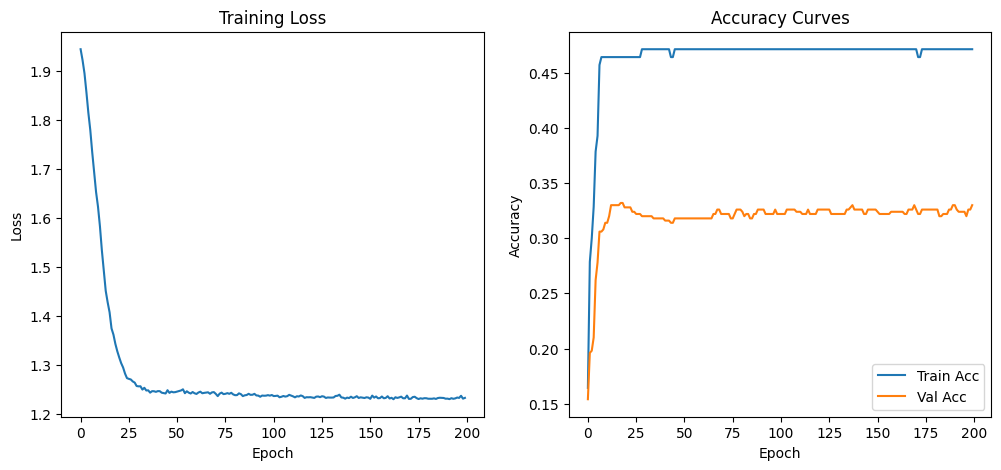

In [74]:
# =====================================
# TRAINING LOOP WITH CURVES
# =====================================

import matplotlib.pyplot as plt

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01,
    weight_decay=5e-4
)

criterion = nn.CrossEntropyLoss()

train_mask = data.train_mask
val_mask = data.val_mask
test_mask = data.test_mask

best_val_acc = 0
patience = 50
patience_counter = 0
best_model_state = None

# ---- Track Metrics ----
train_losses = []
train_accs = []
val_accs = []

for epoch in range(1, 201):

    model.train()
    optimizer.zero_grad()

    out = model(data.x, G)
    loss = criterion(out[train_mask], data.y[train_mask])
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        out = model(data.x, G)
        pred = out.argmax(dim=1)

        train_acc = (pred[train_mask] == data.y[train_mask]).float().mean()
        val_acc = (pred[val_mask] == data.y[val_mask]).float().mean()
        test_acc = (pred[test_mask] == data.y[test_mask]).float().mean()

    # ---- Store metrics ----
    train_losses.append(loss.item())
    train_accs.append(train_acc.item())
    val_accs.append(val_acc.item())

    # ---- Early stopping ----
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | "
              f"Loss: {loss:.4f} | "
              f"Train Acc: {train_acc:.4f} | "
              f"Val Acc: {val_acc:.4f} | "
              f"Test Acc: {test_acc:.4f}")

    # if patience_counter >= patience:
    #     print("Early stopping triggered.")
    #     break

# Load best model
model.load_state_dict(best_model_state)

# Final test accuracy
model.eval()
with torch.no_grad():
    out = model(data.x, G)
    pred = out.argmax(dim=1)
    final_test_acc = (pred[test_mask] == data.y[test_mask]).float().mean()

print("\nFinal Test Accuracy:", final_test_acc.item())

# =====================================
# Plot Curves
# =====================================

plt.figure(figsize=(12,5))

# Loss Curve
plt.subplot(1,2,1)
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Accuracy Curve
plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.title("Accuracy Curves")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()
